In [1]:
!pip install numpy pandas scipy scikit-learn tensorflow matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from google.colab import files

In [3]:
WINDOW_SIZE = 128

CLASS_FILES = {
    "circle": "Circle.csv",
    "left_right": "Left-right.csv",
    "rest": "Rest.csv",
    "up_down": "Up-down.csv"
}

In [4]:
import os

for label, fname in CLASS_FILES.items():
    print(label, "->", fname, "exists:", os.path.exists(fname))

circle -> Circle.csv exists: False
left_right -> Left-right.csv exists: False
rest -> Rest.csv exists: False
up_down -> Up-down.csv exists: False


In [5]:
def load_windows_from_csv(filepath, window_size=128):
    import pandas as pd
    import numpy as np

    df = pd.read_csv(filepath)

    if len(df.columns) == 1:
        col = df.columns[0]
        df = df[col].str.split(',', expand=True)
        df.columns = ['aX','aY','aZ','gX','gY','gZ']

    df = df.apply(pd.to_numeric, errors='coerce')

    df = df.dropna().reset_index(drop=True)

    values = df.values.astype(np.float32)

    num_windows = len(values) // window_size
    values = values[:num_windows * window_size]

    windows = values.reshape(num_windows, window_size, 6)

    return windows

In [7]:
all_data = {}

for label, filepath in CLASS_FILES.items():
    windows = load_windows_from_csv(filepath, WINDOW_SIZE)
    all_data[label] = windows
    print(label, windows.shape)

circle (80, 128, 6)
left_right (80, 128, 6)
rest (80, 128, 6)
up_down (80, 128, 6)


In [8]:
from scipy.signal import welch
import numpy as np

def extract_features_from_window(window, fs=100):
    features = []

    for axis in range(window.shape[1]):
        signal = window[:, axis]

        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms_val = np.sqrt(np.mean(signal ** 2))
        min_val = np.min(signal)
        max_val = np.max(signal)
        range_val = np.max(signal) - np.min(signal)
        mav_val = np.mean(np.abs(signal))
        energy_val = np.sum(signal ** 2)

        freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 64))
        dominant_freq = freqs[np.argmax(psd)]
        peak_psd = np.max(psd)

        features.extend([
            mean_val,
            std_val,
            rms_val,
            min_val,
            max_val,
            dominant_freq,
            peak_psd
        ])

    return np.array(features, dtype=np.float32)

In [9]:
def extract_features_configurable(window, mode="full", fs=100):
    features = []

    for axis in range(window.shape[1]):
        signal = window[:, axis]

        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms_val = np.sqrt(np.mean(signal ** 2))
        min_val = np.min(signal)
        max_val = np.max(signal)

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=min(len(signal), 64)
        )

        dominant_freq = freqs[np.argmax(psd)]
        peak_psd = np.max(psd)

        if mode == "full":
            axis_features = [
                mean_val,
                std_val,
                rms_val,
                min_val,
                max_val,
                dominant_freq,
                peak_psd
            ]

        elif mode == "medium":
            axis_features = [
                mean_val,
                std_val,
                rms_val,
                dominant_freq
            ]

        elif mode == "tiny":
            axis_features = [
                std_val,
                rms_val,
                max_val
            ]

        else:
            raise ValueError("mode must be: full, medium, or tiny")

        features.extend(axis_features)

    return np.array(features, dtype=np.float32)

In [10]:
sample_window = all_data["circle"][0]

print("Full:",
      extract_features_configurable(sample_window, "full").shape)

print("Medium:",
      extract_features_configurable(sample_window, "medium").shape)

print("Tiny:",
      extract_features_configurable(sample_window, "tiny").shape)

Full: (42,)
Medium: (24,)
Tiny: (18,)


In [12]:
class_names = ["circle", "left_right", "rest", "up_down"]

In [13]:
feature_modes = ["full", "medium", "tiny"]

datasets = {}

for mode in feature_modes:
    X = []
    y = []

    for label_idx, label in enumerate(class_names):
        for window in all_data[label]:
            features = extract_features_configurable(
                window,
                mode=mode,
                fs=100
            )

            X.append(features)
            y.append(label_idx)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    datasets[mode] = {
        "X": X,
        "y": y
    }

    print(
        f"{mode.upper():6s} -> "
        f"X shape: {X.shape}, "
        f"y shape: {y.shape}"
    )

FULL   -> X shape: (320, 42), y shape: (320,)
MEDIUM -> X shape: (320, 24), y shape: (320,)
TINY   -> X shape: (320, 18), y shape: (320,)


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

y = datasets["full"]["y"]
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=y[train_idx]
)

print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Train samples: 204
Validation samples: 52
Test samples: 64


In [15]:
from sklearn.preprocessing import StandardScaler

prepared_data = {}
scalers = {}

for mode in ["full", "medium", "tiny"]:
    X = datasets[mode]["X"]
    y = datasets[mode]["y"]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    scalers[mode] = scaler

    prepared_data[mode] = {
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_val": X_val_scaled,
        "y_val": y_val,
        "X_test": X_test_scaled,
        "y_test": y_test
    }

    print(
        f"{mode.upper():6s} -> "
        f"Train: {X_train_scaled.shape}, "
        f"Val: {X_val_scaled.shape}, "
        f"Test: {X_test_scaled.shape}"
    )

FULL   -> Train: (204, 42), Val: (52, 42), Test: (64, 42)
MEDIUM -> Train: (204, 24), Val: (52, 24), Test: (64, 24)
TINY   -> Train: (204, 18), Val: (52, 18), Test: (64, 18)


In [17]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim, num_classes=4):
    model = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("build_model is ready.")

build_model is ready.


In [18]:
models = {}
histories = {}
test_results = {}

for mode in ["full", "medium", "tiny"]:
    print("\n" + "=" * 50)
    print(f"Training {mode.upper()} model")
    print("=" * 50)

    data = prepared_data[mode]

    model = build_model(
        input_dim=data["X_train"].shape[1],
        num_classes=len(class_names)
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],
        validation_data=(
            data["X_val"],
            data["y_val"]
        ),
        epochs=150,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )

    models[mode] = model
    histories[mode] = history
    test_results[mode] = {
        "loss": test_loss,
        "accuracy": test_accuracy,
        "epochs": len(history.history["loss"])
    }

    print(f"Epochs:        {len(history.history['loss'])}")
    print(f"Test loss:     {test_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")


Training FULL model
Epochs:        150
Test loss:     0.0005
Test accuracy: 1.0000

Training MEDIUM model
Epochs:        150
Test loss:     0.0001
Test accuracy: 1.0000

Training TINY model
Epochs:        150
Test loss:     0.0002
Test accuracy: 1.0000


In [ ]:
X = []
y = []

label_to_index = {label: idx for idx, label in enumerate(CLASS_FILES.keys())}
index_to_label = {idx: label for label, idx in label_to_index.items()}

for label, windows in all_data.items():
    for window in windows:
        feats = extract_features_from_window(window, fs=100)
        X.append(feats)
        y.append(label_to_index[label])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature dimension:", X.shape[1])
print("Labels:", label_to_index)

X shape: (320, 42)
y shape: (320,)
Feature dimension: 42
Labels: {'circle': 0, 'left_right': 1, 'rest': 2, 'up_down': 3}


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (192, 42) (192,)
Val: (64, 42) (64,)
Test: (64, 42) (64,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (192, 42)


In [ ]:
import tensorflow as tf

num_classes = len(CLASS_FILES)
input_dim = X_train_scaled.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,964 (19.39 KB)

 Trainable params: 4,964 (19.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class_weight = {
    0: 1.0,   # circle
    1: 1.5,   # left_right
    2: 1.0,   # rest
    3: 1.0    # up_down
}

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=8,
    verbose=1
)

Epoch 1/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9115 - loss: 0.5779 - val_accuracy: 1.0000 - val_loss: 0.2102
Epoch 2/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0991 - val_accuracy: 1.0000 - val_loss: 0.0439
Epoch 3/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0171
Epoch 4/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 5/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0072
Epoch 6/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 7/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 8/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss

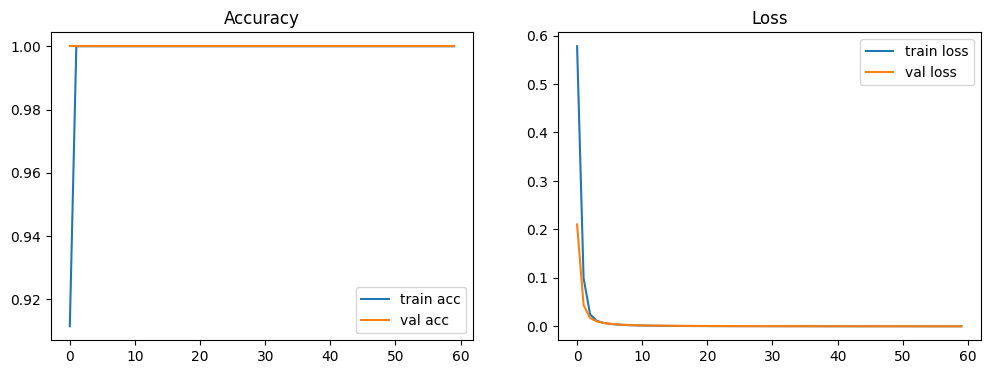

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.savefig("training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        16
  left_right       1.00      1.00      1.00        16
        rest       1.00      1.00      1.00        16
     up_down       1.00      1.00      1.00        16

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



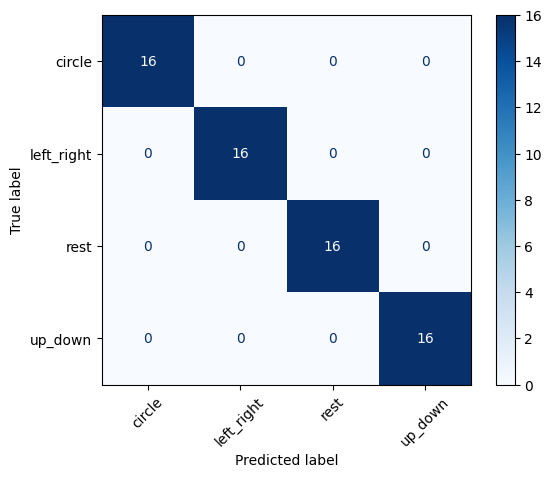

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_test, y_pred, target_names=list(CLASS_FILES.keys()))
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(CLASS_FILES.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved gesture_model.tflite")

Saved artifact at '/tmp/tmpes7vf8w2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137391605316880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137391605312464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137391605308048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137391605313040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137391605303632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137391605316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved gesture_model.tflite


In [ ]:
!xxd -i gesture_model.tflite > model.h

In [ ]:
np.set_printoptions(suppress=True)

print("SCALER_MEAN = {")
print(", ".join(map(str, scaler.mean_.tolist())))
print("}")

print("\nSCALER_SCALE = {")
print(", ".join(map(str, scaler.scale_.tolist())))
print("}")

SCALER_MEAN = {
0.0028456297841330525, 0.15323115103607657, 0.20991249466411924, -0.21135899900400545, 0.24983598484444278, 4.793294270833333, 0.010060067997470981, -0.09267954183451366, 0.16192201818921603, 0.4710910622185717, -0.4333190759255861, 0.24294787406688556, 4.264322916666667, 0.008400465739974744, -0.13490075709220642, 0.07853449013509817, 0.6600663011583189, -0.32984546727190417, 0.06030338545194051, 14.794921875, 0.0012193116736847938, -1.635650815597425, 15.408058225216033, 15.744528147391975, -36.05111258399362, 31.64354811546703, 7.218424479166667, 60.0580913823408, 0.20706652270261353, 12.766421422866793, 12.910864355391823, -29.940286095409345, 25.015511575543012, 9.814453125, 44.01413348610807, 0.6706116674467921, 41.08685917087132, 41.79945999151096, -65.77205386742328, 82.43560286436696, 5.029296875, 708.5841218412396
}

SCALER_SCALE = {
0.14288585025748984, 0.15666630159036002, 0.1561580142293484, 0.1422546317480074, 0.34996500407577597, 5.846469937476034, 0.0150

In [ ]:
with open("scaler_values.txt", "w") as f:
    f.write("SCALER_MEAN = {\n")
    f.write(", ".join(map(str, scaler.mean_.tolist())))
    f.write("\n}\n\n")
    f.write("SCALER_SCALE = {\n")
    f.write(", ".join(map(str, scaler.scale_.tolist())))
    f.write("\n}\n")

In [ ]:
from google.colab import files

files.download("classification_report.txt")
files.download("confusion_matrix.png")
files.download("training_curves.png")
files.download("gesture_model.tflite")
files.download("model.h")
files.download("scaler_values.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>